# Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [72]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("../../data/machine_learning/bcn_noise_ml_dataset_halved.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (8386, 66)
['street_id', 'noise_day', 'noise_evening', 'noise_night', 'road_length', 'road_category', 'one_way', 'distance_to_road', 'fid', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'catastral_bldg_floors_max_50m', 'catastral_bldg_floors_mean_100m', 'catastral_bldg_floors_max_100m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50', 'TRAM', 'street_length_m', 'daytime_count_100m', 'nighttime_count_100m', 'continuous_count_100m', 'discontinuous_count_100m', 'transport_related_count_100m', 'noise_sensitive_count_100m', 'recreation_green_count_100m', 'support_infrastructure_count_100m', 'daytime_count_per_meter_100m', 'nighttime_count_per_meter_100m', 'continuous_count_per_meter_100m', 'discontinuous_count_per_meter_100m', 'transport_related_count_per_meter_100m', 'noise_sensitive_count_per_meter_100m', 'recreation_green_count_

## Reduce the number of columns

In [6]:
columns = ['noise_day','noise_evening','noise_night', 'road_category', 'road_width', 'openness', 'road_length','osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50', 'edge_betweenness']
dataset_small = dataset[columns]
print(dataset_small.columns.tolist())

['noise_day', 'noise_evening', 'noise_night', 'road_category', 'road_width', 'openness', 'road_length', 'osm_commercial_pct_50m', 'osm_green_pct_50m', 'osm_industrial_pct_50m', 'osm_other_pct_50m', 'osm_residential_pct_50m', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'tree_count_50', 'transport_count_50', 'edge_betweenness']


<Axes: >

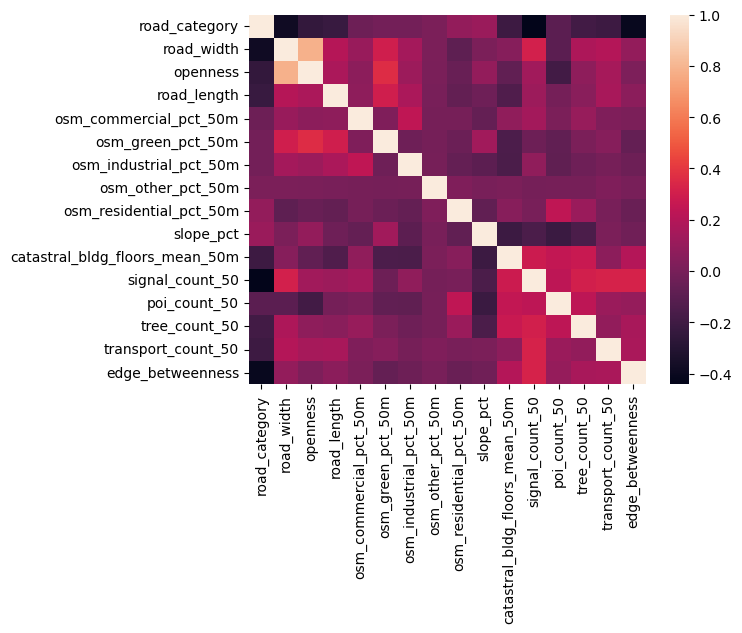

In [7]:
dataset_num = dataset_small.drop(columns=['noise_day', 'noise_evening', 'noise_night']) #dropping y and non-numeric columns
sns.heatmap(dataset_num.corr())

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers 

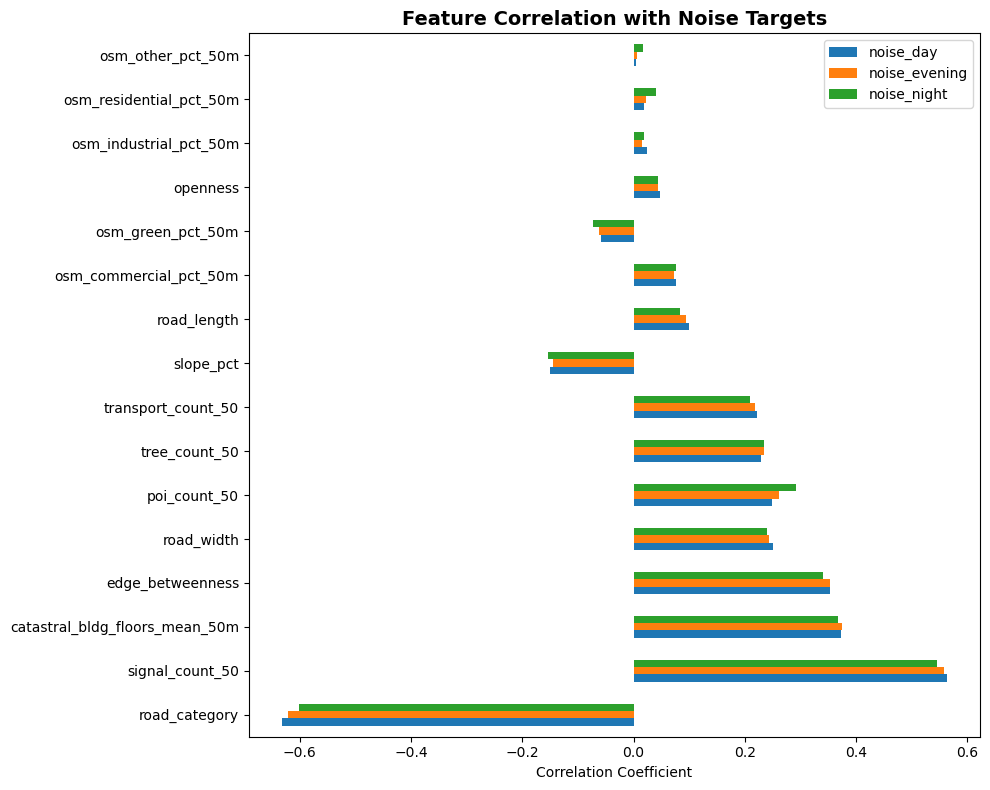

                                noise_day  noise_evening  noise_night
signal_count_50                  0.563049       0.557488     0.545095
catastral_bldg_floors_mean_50m   0.373184       0.374266     0.367058
edge_betweenness                 0.353645       0.353185     0.339917
road_width                       0.251046       0.243865     0.239440
poi_count_50                     0.249438       0.261028     0.291987
tree_count_50                    0.229094       0.234321     0.234143
transport_count_50               0.222093       0.218731     0.208601
road_length                      0.099990       0.094215     0.083960
osm_commercial_pct_50m           0.076721       0.073068     0.076501
openness                         0.048143       0.043031     0.044157
osm_industrial_pct_50m           0.023468       0.014782     0.019106
osm_residential_pct_50m          0.018147       0.023123     0.039531
osm_other_pct_50m                0.003525       0.007057     0.016249
osm_green_pct_50m   

In [15]:
# Extract correlations with noise predictions
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_small.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

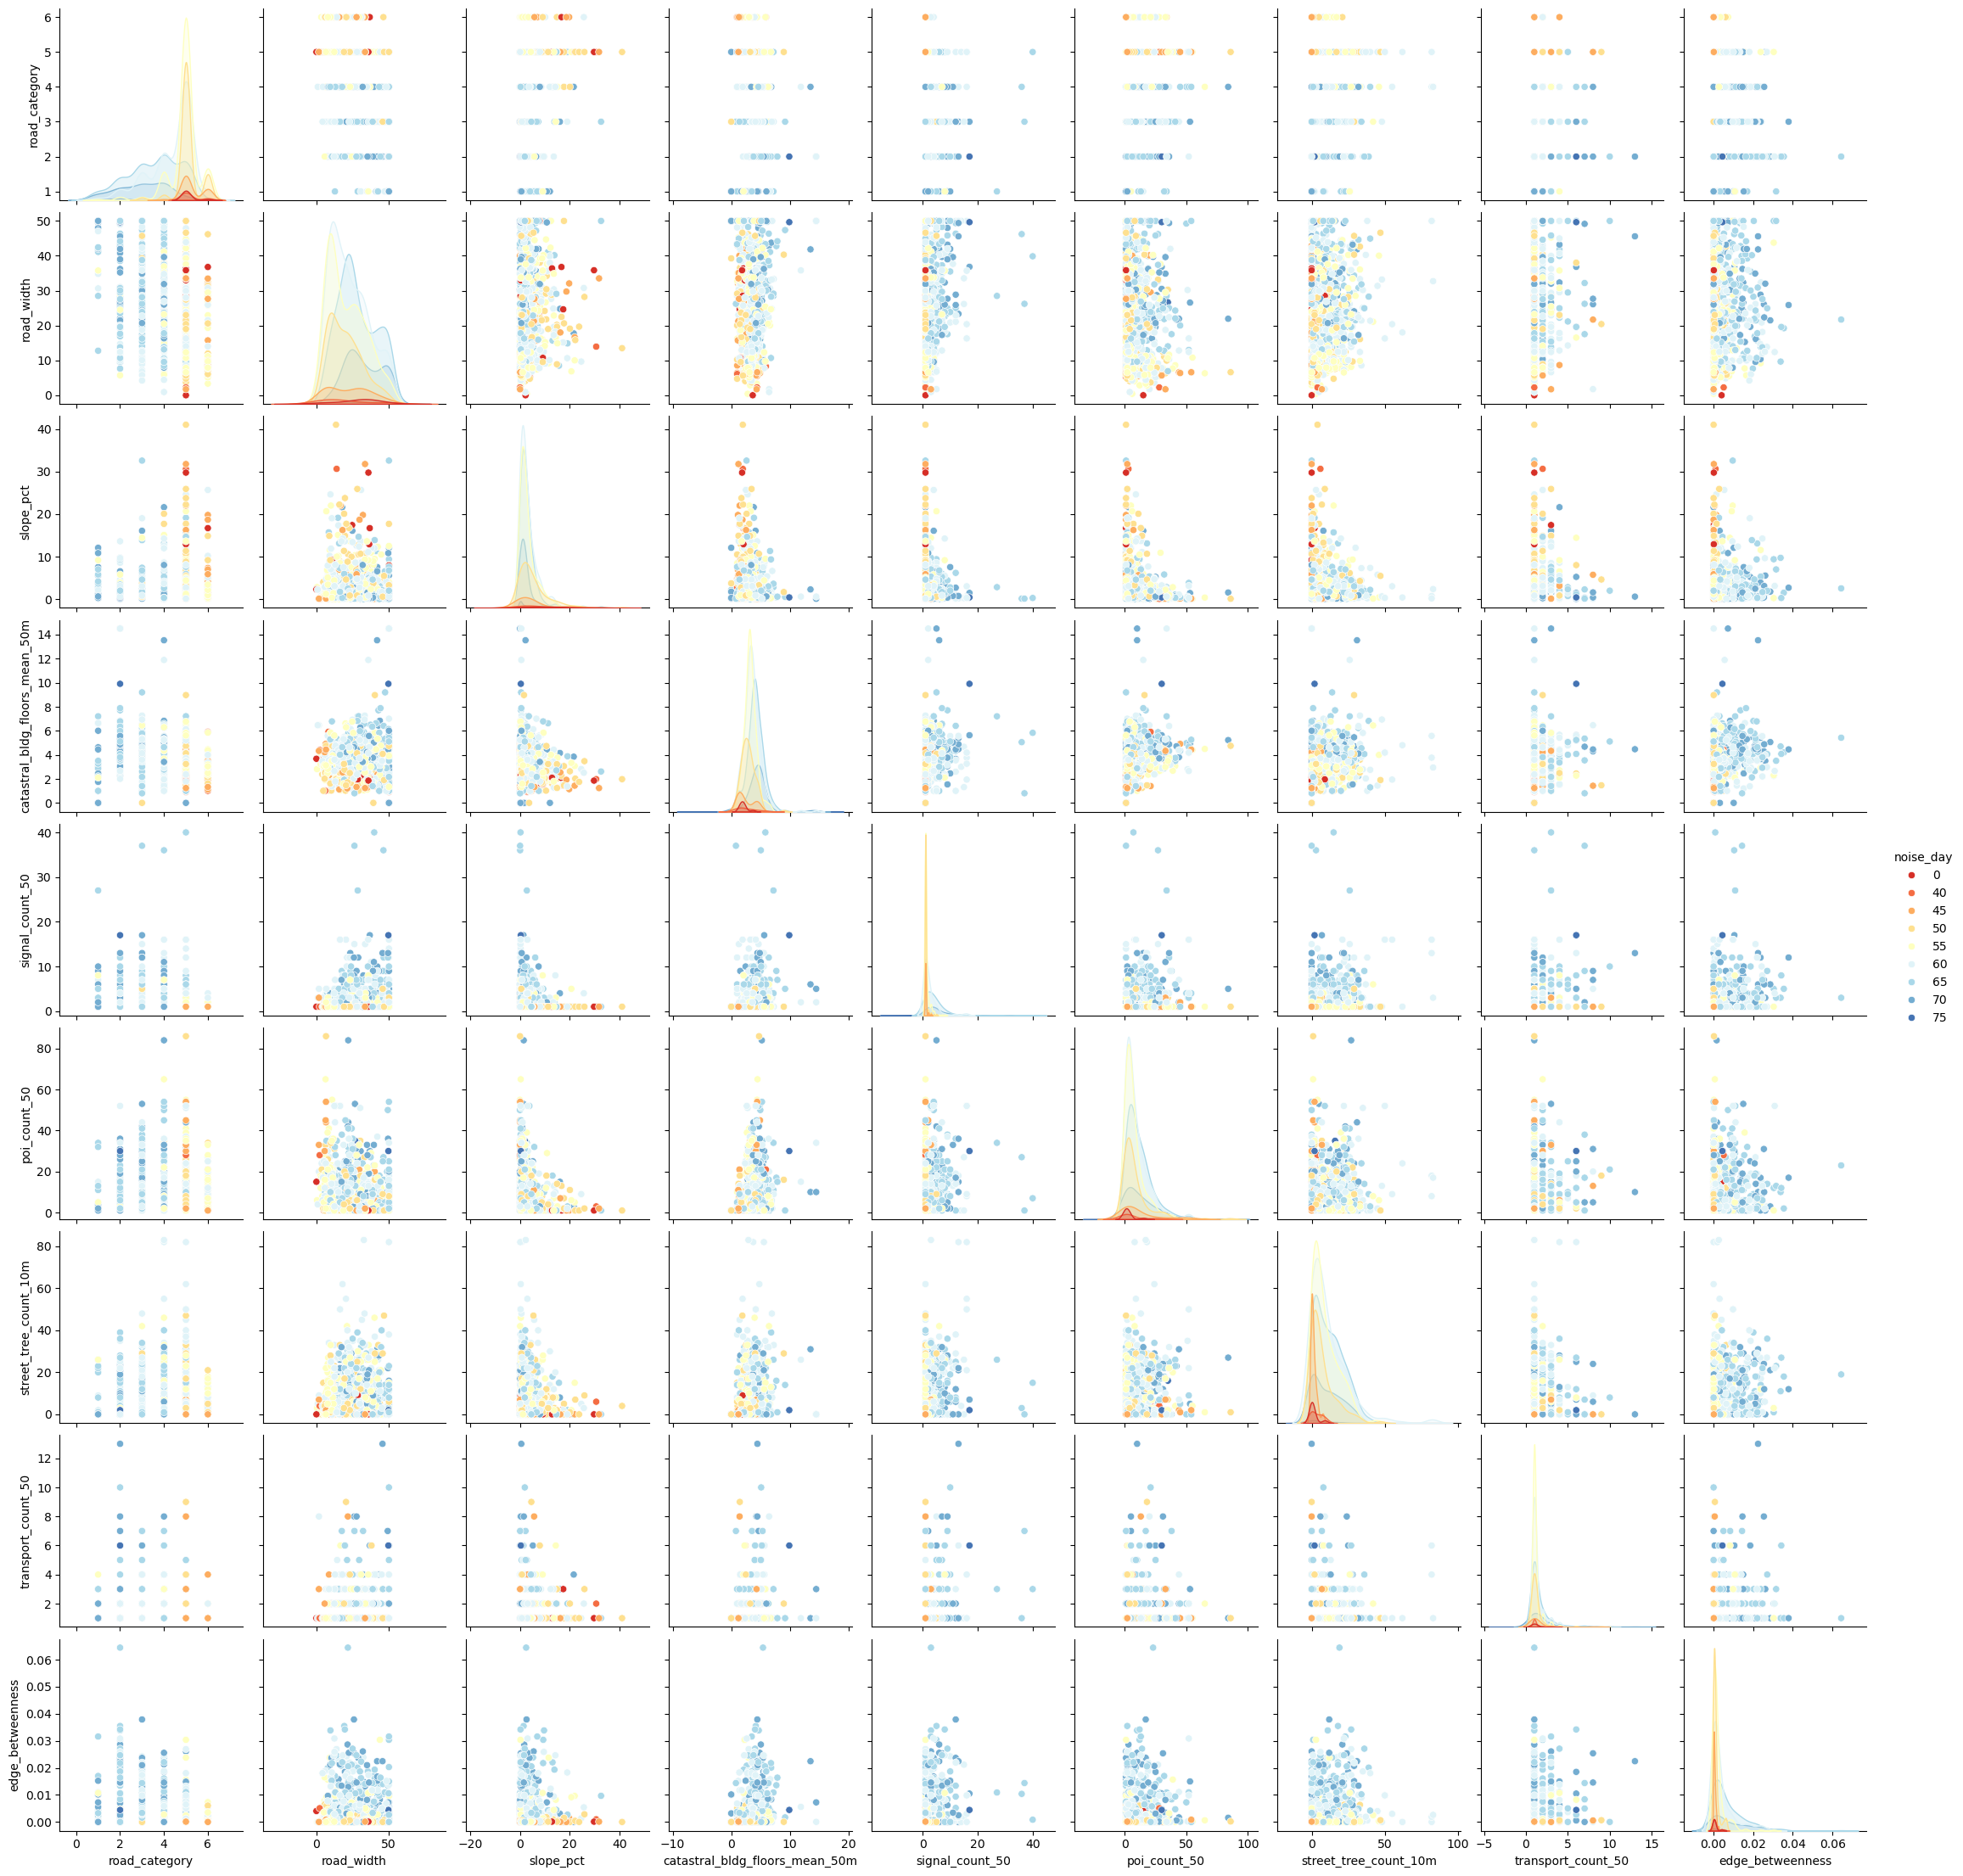

In [30]:
dataset_extra_small = dataset[['noise_day','road_category', 'road_width', 'slope_pct', 'catastral_bldg_floors_mean_50m', 'signal_count_50', 'poi_count_50', 'street_tree_count_10m', 'transport_count_50','edge_betweenness']]

# Sample randomly
sample = dataset_extra_small.sample(n=1000, random_state=42).copy()

# Get unique noise_day values sorted and convert to ordered categorical
sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

sns.pairplot(sample, hue="noise_day", palette="RdYlBu", corner=False)

In [24]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())


Noise Day values:
[55 50 45 60 65 70 40  0 75]

Unique values count: 9
